In [1]:
# IMPORTAR LIBRERÍAS

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.10.0


In [2]:
# PARÁMETROS DEL MODELO

IMG_SIZE = 224      # Tamaño estándar para EfficientNetB0
BATCH_SIZE = 32     # Cantidad de imágenes por paso
EPOCHS = 5          # Número de veces que verá el dataset completo

NUM_CLASSES = 10    # Tienes 10 clases

In [3]:
# PREPROCESAMIENTO DE IMÁGENES

base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,        # Normaliza pixeles (0-255 → 0-1)
    validation_split=0.2                            # 20% validación
)

# Crear Dataset de Entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Crear Dataset de Validación
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 6795 images belonging to 10 classes.
Found 1698 images belonging to 10 classes.


In [4]:
# CARGAR EFFICIENTNET-B0

base_model = EfficientNetB0(
    weights='imagenet',                 # Usa pesos ya entrenados
    include_top=False,                  # Quitamos la capa final original
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False            # Congelamos la red base

In [5]:
# CREAR CAPA FINAL PERSONALIZADA

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [6]:
# COMPILAR MODELO

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 4,214,829
Trainable params: 165,258
Non-trainable params: 4,049,571
________________________________________

In [ ]:
# ENTRENAMIENTO

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/5
213/213 [==============================] - 191s 842ms/step - loss: 0.7509 - accuracy: 0.7572 - val_loss: 0.3522 - val_accuracy: 0.8969
Epoch 2/5
108/213 [==============>...............] - ETA: 1:09 - loss: 0.3657 - accuracy: 0.8821

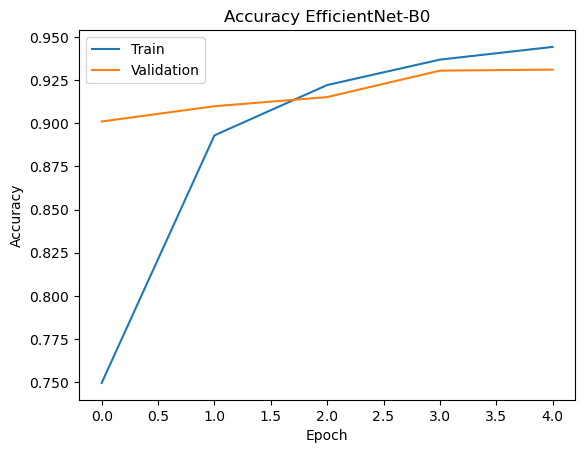

In [ ]:
# GRÁFICAS DE ENTRENAMIENTO

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy EfficientNet-B0')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
# MÉTRICAS

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import seaborn as sns
import numpy as np

val_generator.reset()

predicciones = model.predict(
    val_generator,
    steps=val_generator.samples // BATCH_SIZE + 1
)

y_pred = np.argmax(predicciones, axis=1)
y_true = val_generator.classes

54/54 [==============================] - 36s 635ms/step


[[100   0   0   0   0   0   0   0   0   0]
 [  0 187   0   0   5   1   2   5   0   0]
 [  0   0 139   0   0   0   1   0   0   0]
 [  0  23   0 166   2   5   1   3   0   0]
 [  0   0   0   1 192   0   0   7   0   0]
 [  0   1   0   1   1 196   1   0   0   0]
 [  0   3   0   0   4   8 181   4   0   0]
 [  0   0   0   0   4   0   0 196   0   0]
 [  0   0   0   0   0   0   0   0  58   0]
 [  0   1   2   0   0  26   3   2   0 165]]


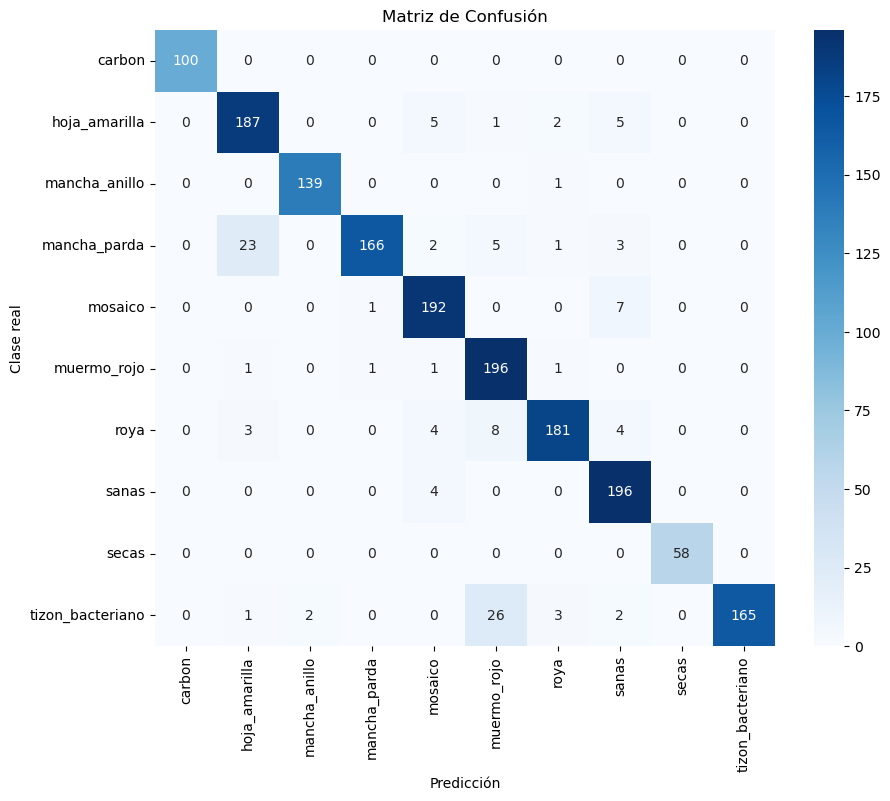

In [ ]:
# MATRIZ DE CONFUSIÓN

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_generator.class_indices.keys(),
    yticklabels=train_generator.class_indices.keys()
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
# F1 SCORE

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.9309209337582626


In [ ]:
# REPORTE DE CLASIFICACIÓN

print(classification_report(
    y_true,
    y_pred,
    target_names=train_generator.class_indices.keys()
))

                  precision    recall  f1-score   support

          carbon       1.00      1.00      1.00       100
   hoja_amarilla       0.87      0.94      0.90       200
   mancha_anillo       0.99      0.99      0.99       140
    mancha_parda       0.99      0.83      0.90       200
         mosaico       0.92      0.96      0.94       200
     muermo_rojo       0.83      0.98      0.90       200
            roya       0.96      0.91      0.93       200
           sanas       0.90      0.98      0.94       200
           secas       1.00      1.00      1.00        58
tizon_bacteriano       1.00      0.83      0.91       199

        accuracy                           0.93      1697
       macro avg       0.95      0.94      0.94      1697
    weighted avg       0.94      0.93      0.93      1697



In [ ]:
# GUARDAR EL MODELO

model.save("modelo_EfficientNetB0_tesis.h5")

TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.